#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.


### CHAPTER 20
**CH20A Working from home and employee performance**

using the wfh dataset

version 1.0 2021-05-05

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from plotnine import *
from stargazer.stargazer import Stargazer

warnings.filterwarnings("ignore")


### Load data

In [9]:
data = pd.read_csv("/workspaces/codespaces-jupyter/data/wfh_tidy_person.csv")

In [10]:
data.columns

Index(['personid', 'treatment', 'ordertaker', 'type', 'quitjob', 'age',
       'costofcommute', 'children', 'male', 'married', 'perform10',
       'perform11', 'prior_experience', 'tenure', 'basewage', 'bonus',
       'grosswage', 'ageyoungestchild', 'rental', 'bedroom',
       'second_technical', 'high_school', 'tertiary_technical', 'university',
       'internet', 'phonecalls0', 'phonecalls1'],
      dtype='object')

In [11]:
data["phonecalls1"]

0       0.000
1      21.797
2       0.000
3       0.000
4       0.000
        ...  
244     0.539
245    12.975
246     0.000
247     9.589
248    10.459
Name: phonecalls1, Length: 249, dtype: float64

### Balance

In [12]:
data["ageyoungestchild"] = np.where(
    data["children"] == 0, np.nan, data["ageyoungestchild"]
)

In [13]:
data["ageyoungestchild"]

0      10.0
1       NaN
2      11.0
3       NaN
4       0.0
       ... 
244     NaN
245     NaN
246     NaN
247     NaN
248     NaN
Name: ageyoungestchild, Length: 249, dtype: float64

In [ ]:
data.dtypes

personid                int64
treatment               int64
ordertaker               bool
type                    int64
quitjob                 int64
age                     int64
costofcommute         float64
children                int64
male                    int64
married                 int64
perform10             float64
perform11             float64
prior_experience      float64
tenure                float64
basewage              float64
bonus                 float64
grosswage             float64
ageyoungestchild      float64
rental                  int64
bedroom                 int64
second_technical        int64
high_school             int64
tertiary_technical      int64
university              int64
internet                int64
phonecalls0           float64
phonecalls1           float64
dtype: object

In [16]:
# convertin nonnumeric dummies to numeric
data["ordertaker"] = data["ordertaker"].astype(int)
#data["children"] = np.where(data["children"] == "yes", 1, 0)
#data["rental"] = np.where(data["rental"] == "yes", 1, 0)
#data["bedroom"] = np.where(data["bedroom"] == "yes", 1, 0)
#data["ageyoungestchild"] = pd.to_numeric(data["ageyoungestchild"])


In [17]:
data.dtypes

personid                int64
treatment               int64
ordertaker              int64
type                    int64
quitjob                 int64
age                     int64
costofcommute         float64
children                int64
male                    int64
married                 int64
perform10             float64
perform11             float64
prior_experience      float64
tenure                float64
basewage              float64
bonus                 float64
grosswage             float64
ageyoungestchild      float64
rental                  int64
bedroom                 int64
second_technical        int64
high_school             int64
tertiary_technical      int64
university              int64
internet                int64
phonecalls0           float64
phonecalls1           float64
dtype: object

In [18]:
data.columns

Index(['personid', 'treatment', 'ordertaker', 'type', 'quitjob', 'age',
       'costofcommute', 'children', 'male', 'married', 'perform10',
       'perform11', 'prior_experience', 'tenure', 'basewage', 'bonus',
       'grosswage', 'ageyoungestchild', 'rental', 'bedroom',
       'second_technical', 'high_school', 'tertiary_technical', 'university',
       'internet', 'phonecalls0', 'phonecalls1'],
      dtype='object')

In [66]:
data["ordertaker"].value_counts()

ordertaker
1    134
0    115
Name: count, dtype: int64

In [65]:
data[["ordertaker", "phonecalls1"]].where(data["ordertaker"]==0)

,ordertaker,phonecalls1
0,0.0,0.0
1,NaN,NaN
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
244,NaN,NaN
245,NaN,NaN
246,0.0,0.0
247,NaN,NaN


In [19]:
variables = data.columns.tolist()

In [20]:
variables

['personid',
 'treatment',
 'ordertaker',
 'type',
 'quitjob',
 'age',
 'costofcommute',
 'children',
 'male',
 'married',
 'perform10',
 'perform11',
 'prior_experience',
 'tenure',
 'basewage',
 'bonus',
 'grosswage',
 'ageyoungestchild',
 'rental',
 'bedroom',
 'second_technical',
 'high_school',
 'tertiary_technical',
 'university',
 'internet',
 'phonecalls0',
 'phonecalls1']

In [21]:
data.head().T

,0,1,2,3,4
personid,3906.000000,4122.000000,4448.000000,4942.000000,5018.000000
treatment,1.000000,1.000000,0.000000,1.000000,1.000000
ordertaker,0.000000,1.000000,0.000000,0.000000,0.000000
type,2.000000,1.000000,2.000000,4.000000,4.000000
quitjob,0.000000,0.000000,0.000000,0.000000,0.000000
age,33.000000,30.000000,35.000000,27.000000,29.000000
costofcommute,8.000000,18.000000,10.000000,20.000000,15.000000
children,1.000000,0.000000,1.000000,0.000000,1.000000
male,0.000000,0.000000,0.000000,0.000000,0.000000
married,1.000000,0.000000,1.000000,1.000000,1.000000


In [22]:
data.dtypes

personid                int64
treatment               int64
ordertaker              int64
type                    int64
quitjob                 int64
age                     int64
costofcommute         float64
children                int64
male                    int64
married                 int64
perform10             float64
perform11             float64
prior_experience      float64
tenure                float64
basewage              float64
bonus                 float64
grosswage             float64
ageyoungestchild      float64
rental                  int64
bedroom                 int64
second_technical        int64
high_school             int64
tertiary_technical      int64
university              int64
internet                int64
phonecalls0           float64
phonecalls1           float64
dtype: object

In [23]:
mean_t = dict()
mean_c = dict()
sd = dict()
p_value = dict()


In [24]:
for i in variables:
    # Regression model
    print(f"{i}: type={type(data[i])}, shape={data[i].shape}")
    data[i] = pd.to_numeric(data[i], errors='coerce')
    model = smf.ols(formula="{i}~treatment".format(i=i), data=data).fit()

    # Mean control
    mean_c[i] = data.loc[data["treatment"] == 0, i].dropna().mean()
    # Mean treated
    mean_t[i] = data.loc[data["treatment"] == 1, i].dropna().mean()
    # p-value from regression
    p_value[i] = model.pvalues[1]
    # Standard deviation
    sd[i] = data[i].dropna().std()


personid: type=<class 'pandas.core.series.Series'>, shape=(249,)
treatment: type=<class 'pandas.core.series.Series'>, shape=(249,)
ordertaker: type=<class 'pandas.core.series.Series'>, shape=(249,)
type: type=<class 'pandas.core.series.Series'>, shape=(249,)
quitjob: type=<class 'pandas.core.series.Series'>, shape=(249,)
age: type=<class 'pandas.core.series.Series'>, shape=(249,)
costofcommute: type=<class 'pandas.core.series.Series'>, shape=(249,)
children: type=<class 'pandas.core.series.Series'>, shape=(249,)
male: type=<class 'pandas.core.series.Series'>, shape=(249,)
married: type=<class 'pandas.core.series.Series'>, shape=(249,)
perform10: type=<class 'pandas.core.series.Series'>, shape=(249,)
perform11: type=<class 'pandas.core.series.Series'>, shape=(249,)
prior_experience: type=<class 'pandas.core.series.Series'>, shape=(249,)
tenure: type=<class 'pandas.core.series.Series'>, shape=(249,)
basewage: type=<class 'pandas.core.series.Series'>, shape=(249,)
bonus: type=<class 'pand

In [26]:
table = pd.DataFrame([mean_t, mean_c, sd, p_value]).T.round(2)
table.columns = [
    "Treatment mean",
    "Control mean",
    "Std.dev.",
    "p-value of test of equal means",
]

table

,Treatment mean,Control mean,Std.dev.,p-value of test of equal means
personid,30299.21,28865.02,11844.94,0.34
treatment,1.00,0.00,0.50,0.00
ordertaker,0.52,0.56,0.50,0.53
type,2.05,1.91,1.27,0.37
quitjob,0.16,0.35,0.43,0.00
age,24.44,24.35,3.55,0.85
costofcommute,7.89,8.34,6.96,0.61
children,0.11,0.24,0.38,0.01
male,0.47,0.47,0.50,0.99
married,0.22,0.32,0.44,0.07


 ### outcomes

In [152]:
# quit firm during 8 months of experiment
# phone calls worked, for order takers


In [29]:
quitjobs = (
    data.groupby("treatment")
    .agg(mean=("quitjob", "mean"), std=("quitjob", "std"), N=("quitjob", "count"))
    .round(3)
)

quitjobs

,mean,std,N
treatment,,,
0,0.347,0.478,118
1,0.160,0.368,131


In [30]:
total_quitjob = data.agg(
    mean_total=("quitjob", "mean"),
    std_total=("quitjob", "std"),
    N_total=("quitjob", "count"),
).T.round(3)

total_quitjob

,mean_total,std_total,N_total
quitjob,0.249,0.433,249.0


In [31]:
# Looking at the data columns, 'perform10' appears to be the metric for phone calls
# for order takers mentioned in the comments in cell 26
phonecalls1 = (
    data.query("ordertaker==1")
    .groupby("treatment")
    .agg(
        mean=("phonecalls1", "mean"),
        std=("phonecalls1", "std"),
        N=("phonecalls1", "count"),
    )
    .round(2)
)
phonecalls1

,mean,std,N
treatment,,,
0,10.06,6.10,66
1,14.10,5.31,68


In [32]:
total_phonecalls = (
    data.query("ordertaker==1")
    .agg(
        mean_total=("phonecalls1", "mean"),
        std_total=("phonecalls1", "std"),
        N_total=("phonecalls1", "count"),
    )
    .T.round(2)
)
total_phonecalls

,mean_total,std_total,N_total
phonecalls1,12.11,6.04,134.0


In [166]:
# Bar chart for quit rates


In [33]:
data["quit_pct"] = data["quitjob"] * 100
data["stayed_pct"] = (1 - data["quitjob"]) * 100


In [34]:
barchart_data = pd.melt(
    data[["treatment", "quit_pct", "stayed_pct"]]
    .groupby("treatment")
    .agg({"quit_pct": "mean", "stayed_pct": "mean"})
    .reset_index(),
    id_vars="treatment",
).rename(columns={"variable": "employees", "value": "pct"})


In [35]:
barchart_data["treatment"] = np.where(
    barchart_data["treatment"] == 0, "Non-treatment group", "Treatment group"
)


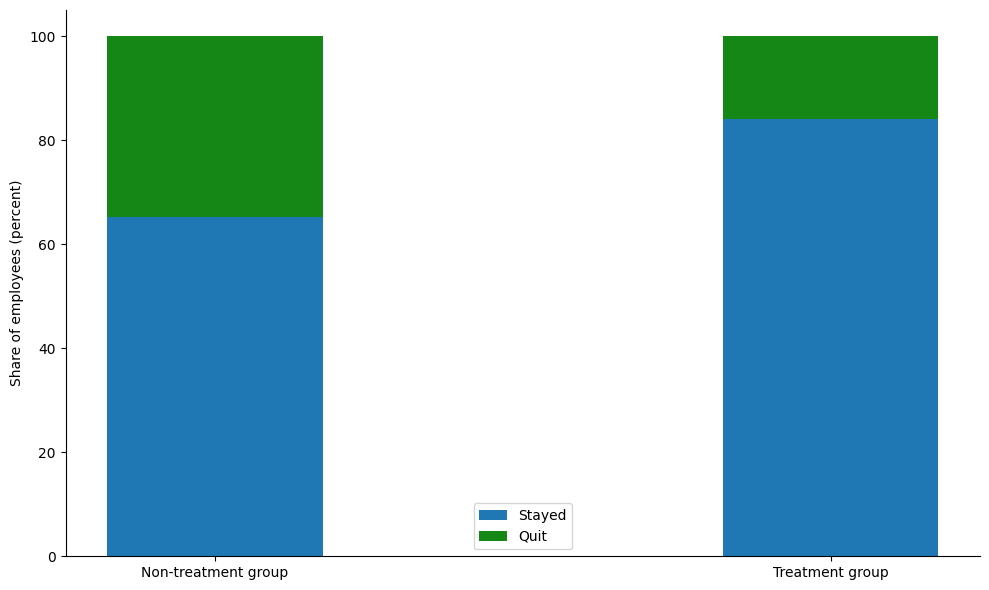

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define colors for the bars
color = ['#1f77b4', "#158717"]  # Blue and Orange colors

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Extract data for plotting
treatment_labels = barchart_data['treatment'].unique()
quit_data = barchart_data[barchart_data['employees'] == 'quit_pct']['pct'].values
stayed_data = barchart_data[barchart_data['employees'] == 'stayed_pct']['pct'].values

# Set positions for bars
x = np.arange(len(treatment_labels))
width = 0.35

# Create bars
ax.bar(x, stayed_data, width, label='Stayed', color=color[0])
ax.bar(x, quit_data, width, bottom=stayed_data, label='Quit', color=color[1])

# Customize plot
ax.set_ylabel('Share of employees (percent)')
ax.set_xticks(x)
ax.set_xticklabels(treatment_labels)
ax.legend(title='')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [38]:
data_nonquitting = data.query("ordertaker==1 and quitjob==0")
barchart_data = pd.melt(
    data_nonquitting[["treatment", "quit_pct", "stayed_pct"]]
    .groupby("treatment")
    .agg({"quit_pct": "mean", "stayed_pct": "mean"})
    .reset_index(),
    id_vars="treatment",
).rename(columns={"variable": "employees", "value": "pct"})

barchart_data["treatment"] = np.where(
    barchart_data["treatment"] == 0, "Non-treatment group", "Treatment group"
)


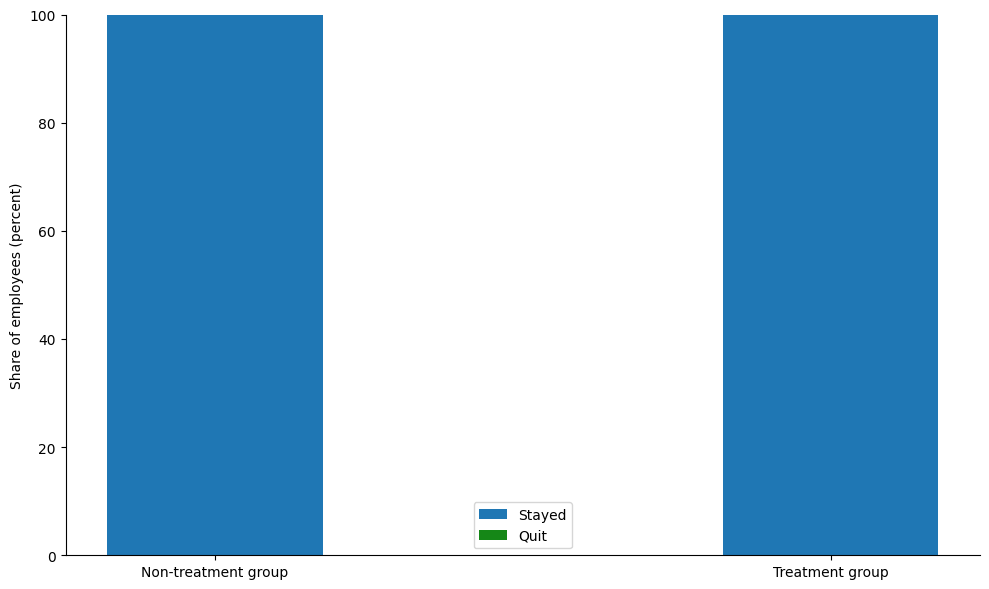

In [39]:
# Define colors for the bars
color = ['#1f77b4', "#158717"]  # Blue and Orange colors

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Extract data for plotting
treatment_labels = barchart_data['treatment'].unique()
quit_data = barchart_data[barchart_data['employees'] == 'quit_pct']['pct'].values
stayed_data = barchart_data[barchart_data['employees'] == 'stayed_pct']['pct'].values

# Set positions for bars
x = np.arange(len(treatment_labels))
width = 0.35

# Create bars
ax.bar(x, stayed_data, width, label='Stayed', color=color[0])
ax.bar(x, quit_data, width, bottom=stayed_data, label='Quit', color=color[1])

# Customize plot
ax.set_ylabel('Share of employees (percent)')
ax.set_xticks(x)
ax.set_xticklabels(treatment_labels)
ax.legend(title='')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Regression analysis 
 Outcome variables: 1) quit firm during 8 months of experiment , 2) phone calls worked, for ordertakers

In [172]:
# Outcomes by treatment

# 1) Quit firm
quitjobs


,mean,std,N
treatment,,,
0,0.347,0.478,118
1,0.160,0.368,131


In [173]:
# 2) Phonecalls (ordertakers only)
phonecalls1


,mean,std,N
treatment,,,
0,10.06,6.10,66
1,14.10,5.31,68


### Regression 1: ATE estimates, no covariates

In [53]:
reg1 = smf.ols(formula="quitjob~treatment", data=data).fit(cov_type="HC1")
reg2 = smf.ols(formula="phonecalls1~treatment", data=data.query("ordertaker==1")).fit(
    cov_type="HC1"
)


In [176]:
stargazer = Stargazer([reg1, reg2])
stargazer.rename_covariates({"Intercept": "Constant"})
HTML(stargazer.render_html())


### Regression 1: ATE estimates, no covariates (with NON-QUITTING)

In [48]:
data_nonquitting[["quitjob","treatment"]].value_counts()

quitjob  treatment
0        1            56
         0            39
Name: count, dtype: int64

In [49]:
data_nonquitting[["phonecalls1","treatment"]].value_counts()

phonecalls1  treatment
12.475       1            2
0.000        0            1
17.679       1            1
17.300       1            1
17.276       0            1
                         ..
13.802       0            1
13.327       0            1
13.267       0            1
13.213       0            1
24.094       1            1
Name: count, Length: 94, dtype: int64

In [50]:
reg21 = smf.ols(formula="phonecalls1~treatment", data=data_nonquitting).fit(
    cov_type="HC1"
)

In [51]:
reg21.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            phonecalls1   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     4.295
Date:                Fri, 29 Aug 2025   Prob (F-statistic):             0.0410
Time:                        18:50:23   Log-Likelihood:                -265.79
No. Observations:                  95   AIC:                             535.6
Df Residuals:                      93   BIC:                             540.7
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.8568      0.658     21.066      0.000      12.568      15.146
treatment      1.7470      0.843      2.072      0.038       0.095       3.399
==============================================================================
Omnibus:                       14.688   Durbin-Watson:                   1.898
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.573
Skew:                          -0.775   Prob(JB):                     9.27e-05
Kurtosis:                       4.513   Cond. No.                         2.88
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [54]:
stargazer = Stargazer([reg2, reg21])
stargazer.rename_covariates({"Intercept": "Constant"})
HTML(stargazer.render_html())

### Regression 2: ATE estimates, with covariates of some unbalance

In [177]:
reg3 = smf.ols(
    formula="quitjob ~ treatment + married + children + internet", data=data
).fit(cov_type="HC1")
reg4 = smf.ols(
    formula="phonecalls1 ~ treatment + married + children + internet",
    data=data.query("ordertaker==1"),
).fit(cov_type="HC1")


In [178]:
stargazer = Stargazer([reg3, reg4])
stargazer.rename_covariates({"Intercept": "Constant"})
HTML(stargazer.render_html())


### Regression 2: ATE estimates, with covariates of some unbalance (only for oder takers)

In [75]:
data.shape

(249, 29)

In [76]:
data_order_taker = data.query("ordertaker==1")
data_order_taker.shape

(134, 29)

In [85]:
reg41 = smf.ols(formula="phonecalls1 ~ treatment + phonecalls0", # Include the number of phone calls before the treatment as a covariate
    data=data_order_taker,
).fit(cov_type="HC1")
reg41.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            phonecalls1   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     29.08
Date:                Fri, 29 Aug 2025   Prob (F-statistic):           3.55e-11
Time:                        19:38:18   Log-Likelihood:                -410.05
No. Observations:                 134   AIC:                             826.1
Df Residuals:                     131   BIC:                             834.8
Df Model:                           2                                         
Covariance Type:                  HC1                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.3703      1.643      0.834      0.404      -1.851       4.591
treatment       4.0030      0.906      4.418      0.000       2.227       5.779
phonecalls0     0.4501      0.083      5.405      0.000       0.287       0.613
==============================================================================
Omnibus:                       11.851   Durbin-Watson:                   1.816
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               13.148
Skew:                          -0.750   Prob(JB):                      0.00140
Kurtosis:                       2.673   Cond. No.                         80.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [86]:
# Define variables to exclude from regression (dependent, treatment, and variables already included)
exclude_vars = ['personid', 'treatment', 'phonecalls1', 'phonecalls0', 'quitjob']

# Create a list of control variables
control_vars = [var for var in variables if var not in exclude_vars]

# Build the formula string with all variables
formula = "phonecalls1 ~ treatment + phonecalls0 + " + " + ".join(control_vars)

# Run the regression with all variables
reg42 = smf.ols(
    formula=formula, 
    data=data_order_taker,
).fit(cov_type="HC1")

reg42.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            phonecalls1   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     274.3
Date:                Fri, 29 Aug 2025   Prob (F-statistic):            0.00364
Time:                        19:38:46   Log-Likelihood:                -32.694
No. Observations:                  20   AIC:                             101.4
Df Residuals:                       2   BIC:                             119.3
Df Model:                          17                                         
Covariance Type:                  HC1                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.8812      5.214      0.553      0.581      -7.337      13.100
treatment              6.2692      6.291      0.997      0.319      -6.061      18.599
phonecalls0           -0.0033      0.631     -0.005      0.996      -1.239       1.233
ordertaker             2.8812      5.214      0.553      0.581      -7.337      13.100
type                   2.8812      5.214      0.553      0.581      -7.337      13.100
age                   -0.1012      0.969     -0.104      0.917      -2.000       1.798
costofcommute         -0.1196      0.162     -0.737      0.461      -0.438       0.199
children               2.8812      5.214      0.553      0.581      -7.337      13.100
male                   0.8473      5.057      0.168      0.867      -9.065      10.760
married                2.8812      5.214      0.553      0.581      -7.337      13.100
perform10              2.9418     10.320      0.285      0.776     -17.286      23.169
perform11              8.5601      8.882      0.964      0.335      -8.847      25.968
prior_experience      -0.0413      0.125     -0.330      0.741      -0.286       0.204
tenure                -0.0267      0.146     -0.183      0.855      -0.314       0.260
basewage              -0.0086      0.022     -0.385      0.700      -0.052       0.035
bonus                 -0.0123      0.005     -2.460      0.014      -0.022      -0.002
grosswage              0.0065      0.006      1.148      0.251      -0.005       0.018
ageyoungestchild       0.9405      1.761      0.534      0.593      -2.511       4.392
rental                -1.5118      5.793     -0.261      0.794     -12.865       9.842
bedroom                2.8812      5.214      0.553      0.581      -7.337      13.100
second_technical      -5.2628      3.481     -1.512      0.131     -12.085       1.559
high_school            2.3261      5.418      0.429      0.668      -8.294      12.946
tertiary_technical    -0.5793      2.748     -0.211      0.833      -5.964       4.806
university             6.3971      9.101      0.703      0.482     -11.440      24.234
internet               2.8812      5.214      0.553      0.581      -7.337      13.100
==============================================================================
Omnibus:                        1.819   Durbin-Watson:                   2.365
Prob(Omnibus):                  0.403   Jarque-Bera (JB):                1.155
Skew:                           0.585   Prob(JB):                        0.561
Kurtosis:                       2.869   Cond. No.                     1.96e+18
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The input rank is higher than the number of observations.
[3] The smallest eigenvalue is 7.96e-29. This m